# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [2]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Double check some datatypes, and for nulls and duplicates:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [7]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [8]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [9]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [10]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [11]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [12]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [13]:
query2 = """
SELECT
    customers.customer_id,
    customers.customer_name,
    ROUND(SUM(order_details.sales), 2) AS total_sales
FROM customers
JOIN orders ON customers.customer_id = orders.customer_id
JOIN order_details ON orders.order_id = order_details.order_id
GROUP BY customers.customer_id, customers.customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""

result2 = pd.read_sql(query2, conn)
result2

,customer_id,customer_name,total_sales
0,KL-16645,Ken Lonsdale,155927.52
1,SE-20110,Sanjit Engle,134303.82
2,CL-12565,Clay Ludtke,130566.55
3,AB-10105,Adrian Barton,130262.14
4,SC-20095,Sanjit Chand,127281.01
5,SM-20320,Sean Miller,125215.25
6,EH-13765,Edward Hooks,123730.56
7,GT-14710,Greg Tran,118201.20
8,SV-20365,Seth Vernon,114709.50
9,JL-15835,John Lee,107799.15


### Which product categories and subcategories are the most profitable overall?

In [14]:
query3 = """
SELECT
  category,
  subcategory,
  SUM(order_details.sales) AS total_sales
FROM order_details
JOIN products ON order_details.product_id = products.product_id
GROUP BY category, subcategory
ORDER BY total_sales DESC;
"""
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,total_sales
0,Technology,Phones,356702.3540
1,Furniture,Chairs,330891.1270
2,Office Supplies,Storage,224958.5600
3,Office Supplies,Binders,211231.7210
4,Furniture,Tables,206965.5320
5,Technology,Machines,194442.8720
6,Technology,Accessories,192960.0260
7,Technology,Copiers,149528.0300
8,Furniture,Bookcases,127801.6393
9,Office Supplies,Appliances,109543.0130


### What is the average discount given per category?

In [15]:
query4 = """
SELECT
  category,
  Discount,
  AVG(Discount) AS avg_discount
FROM order_details
JOIN products ON order_details.product_id = products.product_id
GROUP BY category
ORDER BY avg_discount DESC;
"""
result4 = pd.read_sql(query4, conn)
result4

,category,Discount,avg_discount
0,Furniture,0.0,0.172514
1,Office Supplies,0.0,0.157000
2,Technology,0.2,0.132970


### Which states or regions contribute the most to total sales?

In [16]:
query5 = """
SELECT
    customers.region,
    customers.state,
    ROUND(SUM(order_details.sales), 2) AS total_sales
FROM order_details
JOIN orders ON order_details.order_id = orders.order_id
JOIN customers ON orders.customer_id = customers.customer_id
GROUP BY customers.region, customers.state
ORDER BY total_sales DESC;
"""
result5 = pd.read_sql(query5, conn)
result5

,region,state,total_sales
0,West,California,3314837.69
1,East,New York,1859365.37
2,Central,Texas,1547925.76
3,East,Pennsylvania,886105.68
4,West,Washington,862298.69
5,Central,Illinois,843352.76
6,East,Ohio,707747.69
7,South,Florida,635637.78
8,South,North Carolina,437938.43
9,Central,Michigan,432428.02


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [17]:
query6 = """
SELECT
    COUNT(DISTINCT order_id) AS late_orders
FROM orders
WHERE DATE(ship_date) > DATE(order_date, '+3 days');
"""
result6 = pd.read_sql(query6, conn)
result6

,late_orders
0,3391


### Which month or year had the highest total sales?

In [18]:
query7 = """
SELECT
  STRFTIME('%Y', orders.order_date) AS year,
  ROUND(SUM(order_details.sales), 2) AS total_sales
FROM orders
JOIN order_details ON orders.order_id = order_details.order_id
GROUP BY STRFTIME('%Y', orders.order_date)
ORDER BY total_sales DESC
LIMIT 1;
"""
result7 = pd.read_sql(query7, conn)
result7

,year,total_sales
0,2014,733947.02


### What are the most frequently ordered products?

In [19]:
query8 = """
SELECT
  products.product_id,
  products.product_name,
  COUNT(DISTINCT order_details.order_id) AS times_ordered,
  SUM(order_details.quantity) AS total_quantity_ordered
FROM order_details
JOIN products ON order_details.product_id = products.product_id
GROUP BY products.product_id, products.product_name
ORDER BY total_quantity_ordered DESC, times_ordered DESC
LIMIT 10;
"""
result8 = pd.read_sql(query8, conn)
result8

,product_id,product_name,times_ordered,total_quantity_ordered
0,TEC-AC-10003832,Logitech P710e Mobile Speakerphone,18,75
1,TEC-AC-10003832,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,18,75
2,OFF-PA-10001970,Xerox 1908,18,70
3,OFF-PA-10001970,Xerox 1881,18,70
4,OFF-BI-10001524,GBC Premium Transparent Covers with Diagonal L...,14,67
5,FUR-CH-10002647,"Situations Contoured Folding Chairs, 4/Set",15,64
6,OFF-BI-10002026,Ibico Recycled Linen-Style Covers,14,64
7,OFF-BI-10002026,Avery Arch Ring Binders,14,64
8,FUR-TA-10001095,Chromcraft Round Conference Tables,13,61
9,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,15,60


### Which customers placed more than 5 orders total?

In [20]:
query9 = """
SELECT
  customers.customer_id,
  customers.customer_name,
  COUNT(DISTINCT orders.order_id) AS total_orders
FROM customers
JOIN orders ON customers.customer_id = orders.customer_id
GROUP BY customers.customer_id, customers.customer_name
HAVING COUNT(DISTINCT orders.order_id) > 5
ORDER BY total_orders DESC;
"""
result9 = pd.read_sql(query9, conn)
result9

,customer_id,customer_name,total_orders
0,EP-13915,Emily Phan,17
1,CK-12205,Chloris Kastensmidt,13
2,EA-14035,Erin Ashbrook,13
3,JE-15745,Joel Eaton,13
4,NS-18640,Noel Staavos,13
...,...,...,...
459,TS-21370,Todd Sumrall,6
460,TS-21505,Tony Sayre,6
461,VB-21745,Victoria Brennan,6
462,VD-21670,Valerie Dominguez,6


### What’s the profit margin (profit ÷ sales) by category or segment?

In [21]:
query10 = """
SELECT
  products.category,
  ROUND(SUM(order_details.profit), 2) AS total_profit,
  ROUND(SUM(order_details.sales), 2) AS total_sales,
  ROUND((SUM(order_details.profit) * 100.0) / NULLIF(SUM(order_details.sales), 0), 2) AS profit_margin
FROM order_details
JOIN products
  ON order_details.product_id = products.product_id
GROUP BY products.category
ORDER BY profit_margin DESC;
"""
result10 = pd.read_sql(query10, conn)
result10

,category,total_profit,total_sales,profit_margin
0,Technology,153415.70,893633.28,17.17
1,Office Supplies,126113.35,736748.59,17.12
2,Furniture,20098.89,764284.65,2.63


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

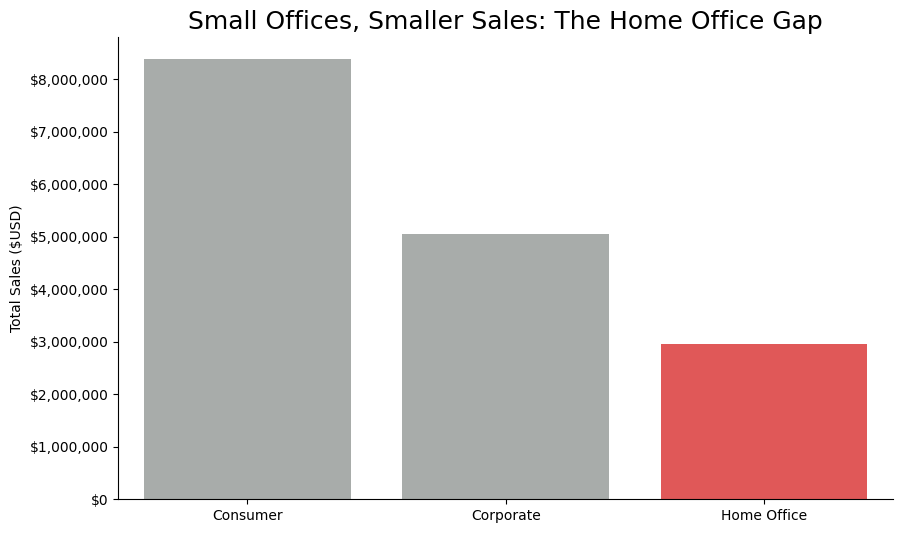

In [22]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


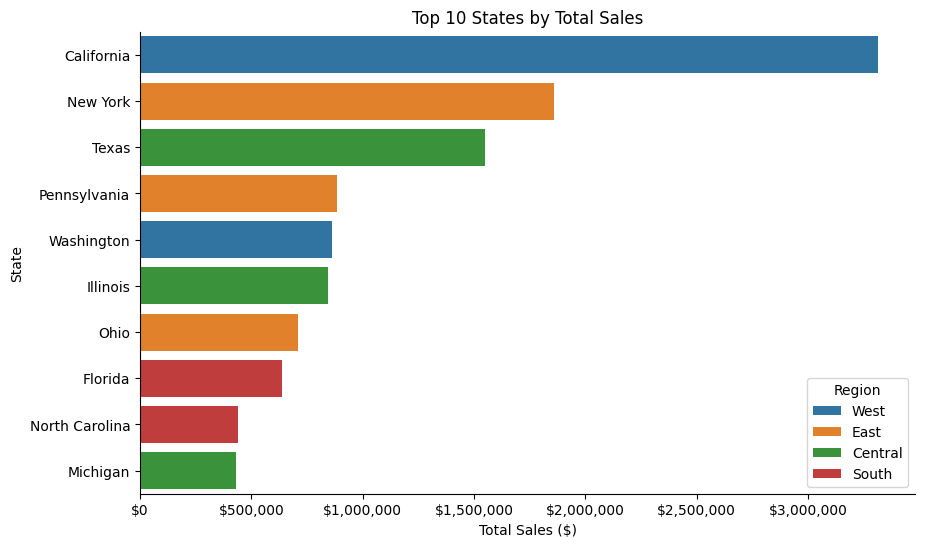

In [23]:
# visualization one code here
plot_result5 = result5.sort_values("total_sales", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_result5, x="total_sales", y="state", hue="region", dodge=False)
plt.title("Top 10 States by Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("State")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()
plt.legend(title="Region")
plt.show()

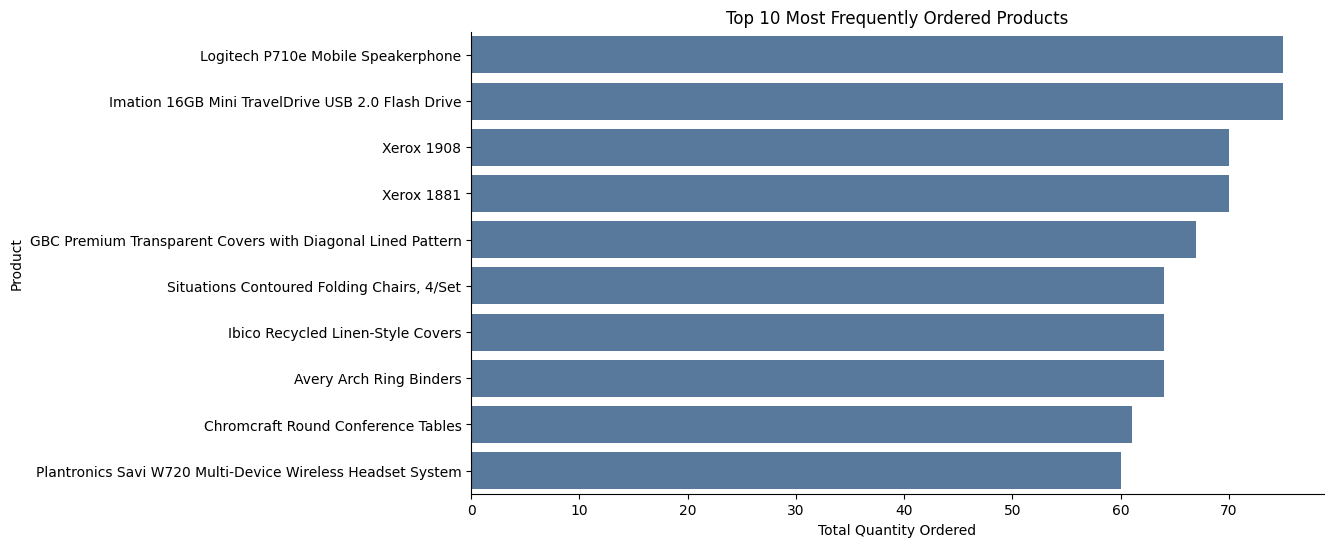

In [24]:
# visualization two code here
plot_result8 = result8.sort_values("total_quantity_ordered", ascending=False).head(10)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_result8, x="total_quantity_ordered", y="product_name", color="#4C78A8")
plt.title("Top 10 Most Frequently Ordered Products")
plt.xlabel("Total Quantity Ordered")
plt.ylabel("Product")
sns.despine()
plt.show()

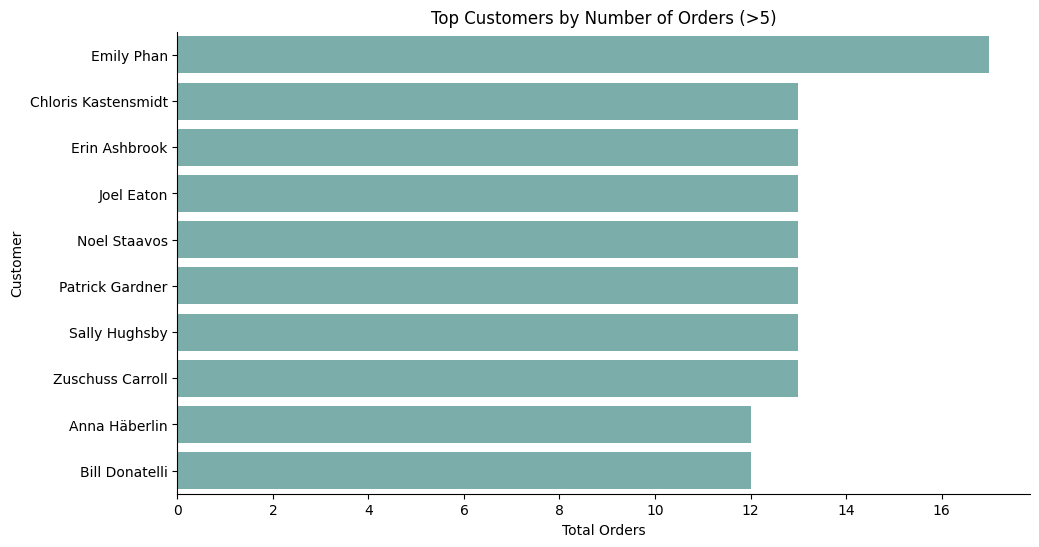

In [25]:
# visualization three code here
plot_result9 = result9.sort_values("total_orders", ascending=False).head(10)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_result9, x="total_orders", y="customer_name", color="#72B7B2")
plt.title("Top Customers by Number of Orders (>5)")
plt.xlabel("Total Orders")
plt.ylabel("Customer")
sns.despine()
plt.show()

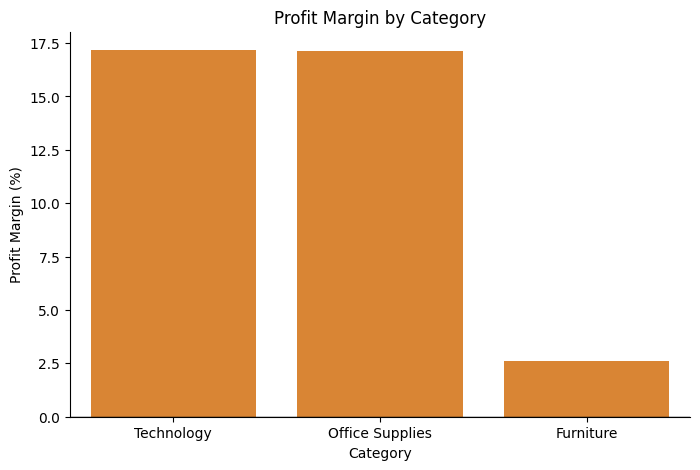

In [26]:
# visualization four code here
plot_result10 = result10.sort_values("profit_margin", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_result10, x="category", y="profit_margin", color="#F58518")
plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.axhline(0, color="black", linewidth=1)
sns.despine()
plt.show()